# Actividad 3er Corte — Programación Dinámica y Control Monte Carlo
## Entorno: FrozenLake8x8

**Integrantes del grupo:** Nicolas Hurtado, Sofia, Mateo Llanos

Este notebook implementa los cinco puntos de la actividad usando el entorno `FrozenLake8x8` de OpenAI Gym:

1. Exploración del entorno y política aleatoria
2. Programación Dinámica (Iteración de Política + Iteración de Valores)
3. Control Monte Carlo on-policy — comparación de ε
4. Efecto del factor de descuento γ
5. Comparación PD vs Monte Carloo

In [2]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Librerias importadas correctamente')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Librerias importadas correctamente


# Actividad 3 – Aprendizaje por Refuerzo
## Entorno: FrozenLake 8×8
---
## 1. Exploración del Entorno

FrozenLake es una cuadrícula 8×8 donde el agente navega desde el inicio **S** (estado 0)
hasta la meta **G** (estado 63), evitando caer en hoyos **H**.

| Tile | Significado |
|------|-------------|
| S | Start – estado inicial (0) |
| F | Frozen – hielo libre, transitable |
| H | Hole – hoyo, estado terminal (R=0) |
| G | Goal – meta, estado terminal (R=1) |

**Propiedad clave:** `is_slippery=True` → con probabilidad 1/3 el agente se mueve
en la dirección deseada; con probabilidad 2/3 se desliza 90° (izquierda o derecha).

In [3]:
# gym >= 0.22 usa v1 (equivalente al v0 del profesor con is_slippery=True)
try:
    entorno = gym.make('FrozenLake8x8-v0')
except Exception:
    entorno = gym.make('FrozenLake8x8-v1', is_slippery=True)

nS = entorno.observation_space.n   # 64 estados
nA = entorno.action_space.n        # 4 acciones
P  = entorno.unwrapped.P           # función de transición

ACCIONES = {0: 'Izquierda', 1: 'Abajo', 2: 'Derecha', 3: 'Arriba'}
print(f'Numero de estados (nS): {nS}')
print(f'Numero de acciones (nA): {nA}')
print(f'Acciones: {ACCIONES}')

Numero de estados (nS): 64
Numero de acciones (nA): 4
Acciones: {0: 'Izquierda', 1: 'Abajo', 2: 'Derecha', 3: 'Arriba'}


In [4]:
# Mostrar el mapa del entorno
mapa = entorno.unwrapped.desc
print('Mapa FrozenLake 8x8 (S=Inicio, F=Hielo, H=Hoyo, G=Meta):')
print()
print('    Col: 0  1  2  3  4  5  6  7')
for i, fila in enumerate(mapa):
    tiles = '  '.join(c.decode() for c in fila)
    print(f'  Fila {i}: {tiles}')
print()
print(f'Estado 0  = S (inicio, esquina superior izquierda)')
print(f'Estado 63 = G (meta,   esquina inferior derecha)')
n_hoyos = sum(c.decode() == 'H' for fila in mapa for c in fila)
print(f'Total de hoyos: {n_hoyos}')

Mapa FrozenLake 8x8 (S=Inicio, F=Hielo, H=Hoyo, G=Meta):

    Col: 0  1  2  3  4  5  6  7
  Fila 0: S  F  F  F  F  F  F  F
  Fila 1: F  F  F  F  F  F  F  F
  Fila 2: F  F  F  H  F  F  F  F
  Fila 3: F  F  F  F  F  H  F  F
  Fila 4: F  F  F  H  F  F  F  F
  Fila 5: F  H  H  F  F  F  H  F
  Fila 6: F  H  F  F  H  F  H  F
  Fila 7: F  F  F  H  F  F  F  G

Estado 0  = S (inicio, esquina superior izquierda)
Estado 63 = G (meta,   esquina inferior derecha)
Total de hoyos: 10


In [5]:
# Requisito: ejecutar un episodio completo con env.render()
print('Episodio con politica ALEATORIA (render paso a paso):')
print()
s = entorno.reset()
paso = 0
done = False
recompensa_total = 0

while not done and paso < 100:
    # Intentar render en modo ansi (texto)
    try:
        salida = entorno.render(mode='ansi')
        if isinstance(salida, str) and salida.strip():
            print(salida)
    except Exception:
        try:
            entorno.render()
        except Exception:
            pass

    a = entorno.action_space.sample()
    s_nuevo, r, done, _ = entorno.step(a)
    print(f'Paso {paso+1:2d}: estado {s:2d} + {ACCIONES[a]:<12} -> estado {s_nuevo:2d} | r={r}')
    s = s_nuevo
    recompensa_total += r
    paso += 1

print()
resultado = 'EXITO' if recompensa_total > 0 else 'FALLO'
print(f'Resultado: {resultado} en {paso} pasos (recompensa acumulada = {recompensa_total})')

Episodio con politica ALEATORIA (render paso a paso):


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  1: estado  0 + Arriba       -> estado  0 | r=0.0
  (Up)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  2: estado  0 + Izquierda    -> estado  0 | r=0.0
  (Left)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  3: estado  0 + Izquierda    -> estado  0 | r=0.0
  (Left)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  4: estado  0 + Abajo        -> estado  1 | r=0.0
  (Down)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  5: estado  1 + Derecha      -> estado  9 | r=0.0
  (Right)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  6: estado  9 + Izquierda    -> estado  1 | r=0.0
  (Left)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

Paso  7: estado  1 + Arriba       -> estado  2 | r

In [6]:
# Requisito: recompensa promedio de la politica aleatoria en 500 episodios
N_ALEATORIO = 500
recompensas_al = []
exitos_al = 0

for _ in range(N_ALEATORIO):
    s = entorno.reset()
    done = False
    r_total = 0
    while not done:
        a = entorno.action_space.sample()
        s, r, done, _ = entorno.step(a)
        r_total += r
    recompensas_al.append(r_total)
    if r_total > 0:
        exitos_al += 1

media_al = float(np.mean(recompensas_al))
std_al   = float(np.std(recompensas_al))
tasa_al  = exitos_al / N_ALEATORIO

print(f'=== Politica Aleatoria ({N_ALEATORIO} episodios) ===')
print(f'Recompensa promedio : {media_al:.4f} +/- {std_al:.4f}')
print(f'Tasa de exito       : {tasa_al:.2%}  ({exitos_al}/{N_ALEATORIO} episodios exitosos)')
print()
print('Esta linea base (baseline) debe ser superada por cualquier algoritmo de RL.')

=== Politica Aleatoria (500 episodios) ===
Recompensa promedio : 0.0040 +/- 0.0631
Tasa de exito       : 0.40%  (2/500 episodios exitosos)

Esta linea base (baseline) debe ser superada por cualquier algoritmo de RL.


In [7]:
# P[s][a] -> [(probabilidad, estado_siguiente, recompensa, terminal), ...]
print('Funcion de transicion: P[s][a] -> [(prob, s_nuevo, reward, done)]')
print()
print('Ejemplo A: estado 0 (S), accion 2 (Derecha):')
for prob, s_, r, done in P[0][2]:
    print(f'  -> estado {s_:2d} | prob={prob:.4f} | r={r} | done={done}')
print()
print('Ejemplo B: estado 62 (F, adyacente a la meta), accion 2 (Derecha):')
for prob, s_, r, done in P[62][2]:
    print(f'  -> estado {s_:2d} | prob={prob:.4f} | r={r} | done={done}')
print()
print('Desde el estado 62, ir a la Derecha puede: llegar a meta (63), caer')
print('en hoyo (54) por deslizamiento, o rebotar en la pared inferior (62).')
print('Cada transicion tiene exactamente prob=1/3 (is_slippery=True).')

Funcion de transicion: P[s][a] -> [(prob, s_nuevo, reward, done)]

Ejemplo A: estado 0 (S), accion 2 (Derecha):
  -> estado  8 | prob=0.3333 | r=0.0 | done=False
  -> estado  1 | prob=0.3333 | r=0.0 | done=False
  -> estado  0 | prob=0.3333 | r=0.0 | done=False

Ejemplo B: estado 62 (F, adyacente a la meta), accion 2 (Derecha):
  -> estado 62 | prob=0.3333 | r=0.0 | done=False
  -> estado 63 | prob=0.3333 | r=1.0 | done=True
  -> estado 54 | prob=0.3333 | r=0.0 | done=True

Desde el estado 62, ir a la Derecha puede: llegar a meta (63), caer
en hoyo (54) por deslizamiento, o rebotar en la pared inferior (62).
Cada transicion tiene exactamente prob=1/3 (is_slippery=True).


In [8]:
print('=' * 60)
print('  DEMOSTRACION DEL EFECTO DE DESLIZAMIENTO (Slipping Effect)')
print('=' * 60)
print()
print('Experimento: desde estado=0, accion=2 (Derecha), repetido 15 veces.')
print('Sin deslizamiento, siempre llegariamos al estado 1.')
print()

conteo = {}
for i in range(15):
    entorno.reset()                        # siempre regresa al estado 0
    s_, r, done, info = entorno.step(2)    # accion: Derecha
    conteo[s_] = conteo.get(s_, 0) + 1
    prob_real = list(info.values())[0] if info else 0.333
    print(f'  Intento {i+1:2d}: estado 0 + Derecha -> estado {s_:2d}  (prob={prob_real:.4f})')

print()
print('Frecuencia de estados alcanzados:')
for estado, veces in sorted(conteo.items()):
    print(f'  Estado {estado:2d}: {veces}/15 veces  ({veces/15:.0%})')
print()
print('Conclusion: misma accion, mismo estado -> resultados distintos.')
print('Esto es el deslizamiento estocastico propio de FrozenLake.')

  DEMOSTRACION DEL EFECTO DE DESLIZAMIENTO (Slipping Effect)

Experimento: desde estado=0, accion=2 (Derecha), repetido 15 veces.
Sin deslizamiento, siempre llegariamos al estado 1.

  Intento  1: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  2: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento  3: estado 0 + Derecha -> estado  1  (prob=0.3333)
  Intento  4: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  5: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  6: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento  7: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  8: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento  9: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento 10: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento 11: estado 0 + Derecha -> estado  0  (prob=0.3333)
  Intento 12: estado 0 + Derecha -> estado  8  (prob=0.3333)
  Intento 13: estado 0 + Derecha -> estado  1  (prob=0.3333)
  Intento 14: estado 0 +

### Análisis – Sección 1

**Estructura del MDP:**
- **64 estados** (cuadrícula 8×8, numerados fila × 8 + columna)
- **4 acciones**: Izquierda (0), Abajo (1), Derecha (2), Arriba (3)
- **Transiciones estocásticas**: prob 1/3 por cada una de las 3 direcciones posibles
- **Recompensa escasa**: R=0 en cada paso; R=1 únicamente al llegar al estado 63 (G)

**Efecto de deslizamiento:**
La demostración muestra que la misma acción desde el mismo estado puede llevar a
estados diferentes. Desde el estado 0 tomando "Derecha", el agente puede terminar en:
- Estado 1 (movimiento intencional, prob≈1/3)
- Estado 0 (desliza hacia arriba → choca pared, prob≈1/3)
- Estado 8 (desliza hacia abajo, prob≈1/3)

**Implicaciones para el aprendizaje:**
- **PD (model-based)**: puede usar P directamente para calcular la política óptima exacta.
- **MC (model-free)**: debe explorar el entorno, acumular episodios y aprender de la experiencia.
  Las recompensas escasas y los episodios largos dificultan la convergencia de MC.

---
## 2. Programación Dinámica (PD)

Métodos **model-based**: requieren conocer la función de transición P.
Resuelven el MDP exactamente usando las ecuaciones de Bellman.

### 2.1 Iteración de Política (PI)
Alterna entre *evaluación* (calcular V bajo la política actual) y
*mejora* (actualizar la política greedy respecto a V) hasta convergencia.

### 2.2 Iteración de Valores (VI)
Aplica directamente la ecuación de optimalidad de Bellman (barrido de V)
hasta que el cambio máximo δ < θ, luego extrae la política greedy.

In [9]:
GAMMA = 0.99    # factor de descuento
THETA = 1e-10   # criterio de convergencia

In [10]:
def calcular_funcion_q(P, nA, V, s, gamma=GAMMA):
    """Q(s,a) = sum_s' P(s'|s,a)[r + gamma*V(s')]"""
    q = np.zeros(nA)
    for a in range(nA):
        for prob, s_, r, done in P[s][a]:
            q[a] += prob * (r + gamma * V[s_])
    return q

def evaluacion_politica(P, nS, nA, politica, gamma=GAMMA, theta=THETA):
    """Evalua V bajo la politica dada; retorna V y lista de deltas por barrido."""
    V = np.zeros(nS)
    deltas = []
    while True:
        delta = 0
        for s in range(nS):
            Vs = 0
            for a, pr in enumerate(politica[s]):
                for prob, s_, r, done in P[s][a]:
                    Vs += pr * prob * (r + gamma * V[s_])
            delta = max(delta, abs(V[s] - Vs))
            V[s] = Vs
        deltas.append(delta)
        if delta < theta:
            break
    return V, deltas

def mejorar_politica(P, nS, nA, V, gamma=GAMMA):
    """Retorna la politica greedy respecto a V."""
    politica = np.zeros([nS, nA])
    for s in range(nS):
        q = calcular_funcion_q(P, nA, V, s, gamma)
        politica[s][np.argmax(q)] = 1
    return politica

In [11]:
def iterar_politica(P, nS, nA, gamma=GAMMA, theta=THETA):
    politica = np.ones([nS, nA]) / nA
    todos_deltas = []
    n_iter = 0
    while True:
        V, deltas = evaluacion_politica(P, nS, nA, politica, gamma, theta)
        todos_deltas.extend(deltas)
        politica_nueva = mejorar_politica(P, nS, nA, V, gamma)
        n_iter += 1
        if (politica_nueva == politica).all():
            break
        politica = np.copy(politica_nueva)
    print(f'PI: {n_iter} mejoras de politica | {len(todos_deltas)} barridos de evaluacion')
    return politica_nueva, V, todos_deltas, n_iter

def iteracion_valores(P, nS, nA, gamma=GAMMA, theta=THETA):
    V = np.zeros(nS)
    deltas = []
    while True:
        delta = 0
        for s in range(nS):
            v = V[s]
            V[s] = max(calcular_funcion_q(P, nA, V, s, gamma))
            delta = max(delta, abs(V[s] - v))
        deltas.append(delta)
        if delta < theta:
            break
    politica = mejorar_politica(P, nS, nA, V, gamma)
    print(f'VI: {len(deltas)} barridos hasta convergencia')
    return politica, V, deltas

def evaluar_politica(entorno, politica, episodios=1000):
    exitos = 0
    for _ in range(episodios):
        s = entorno.reset()
        done = False
        while not done:
            a = np.argmax(politica[s])
            s, r, done, _ = entorno.step(a)
        if r == 1.0:
            exitos += 1
    return exitos / episodios

In [12]:
print('Ejecutando Iteracion de Politica (PI)...')
politica_pi, V_pi, deltas_pi, n_iter_pi = iterar_politica(P, nS, nA)

print()
print('Ejecutando Iteracion de Valores (VI)...')
politica_vi, V_vi, deltas_vi = iteracion_valores(P, nS, nA)

Ejecutando Iteracion de Politica (PI)...
PI: 3 mejoras de politica | 1210 barridos de evaluacion

Ejecutando Iteracion de Valores (VI)...
VI: 440 barridos hasta convergencia


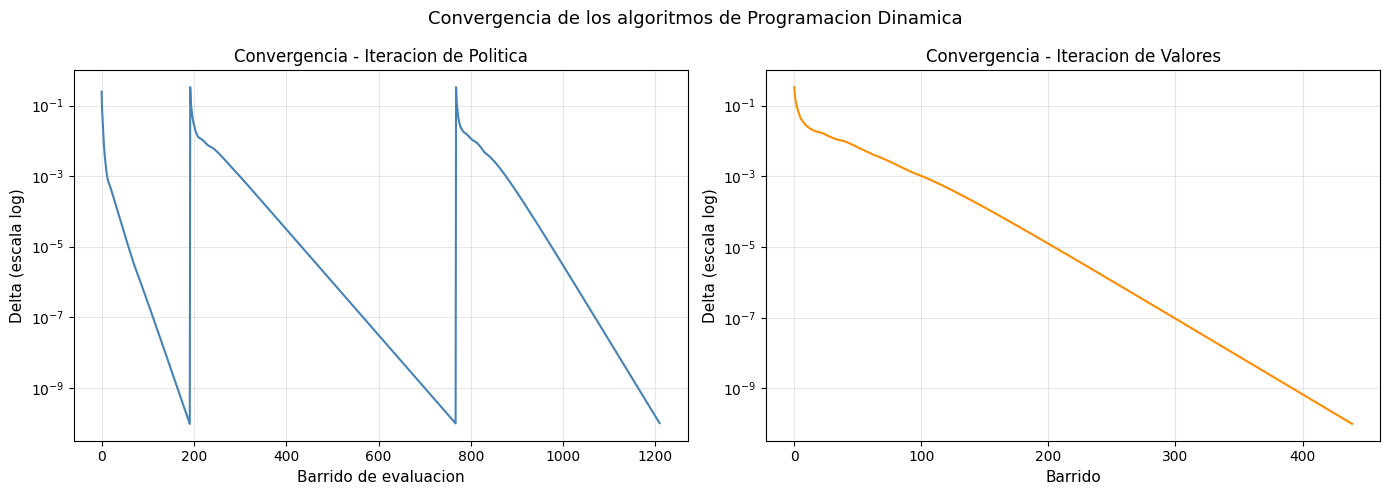

PI: 1210 barridos | VI: 440 barridos


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(deltas_pi, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Barrido de evaluacion', fontsize=11)
ax1.set_ylabel('Delta (escala log)', fontsize=11)
ax1.set_title('Convergencia - Iteracion de Politica', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.semilogy(deltas_vi, color='darkorange', linewidth=1.5)
ax2.set_xlabel('Barrido', fontsize=11)
ax2.set_ylabel('Delta (escala log)', fontsize=11)
ax2.set_title('Convergencia - Iteracion de Valores', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle('Convergencia de los algoritmos de Programacion Dinamica', fontsize=13)
plt.tight_layout()
plt.savefig('pd_convergencia.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'PI: {len(deltas_pi)} barridos | VI: {len(deltas_vi)} barridos')

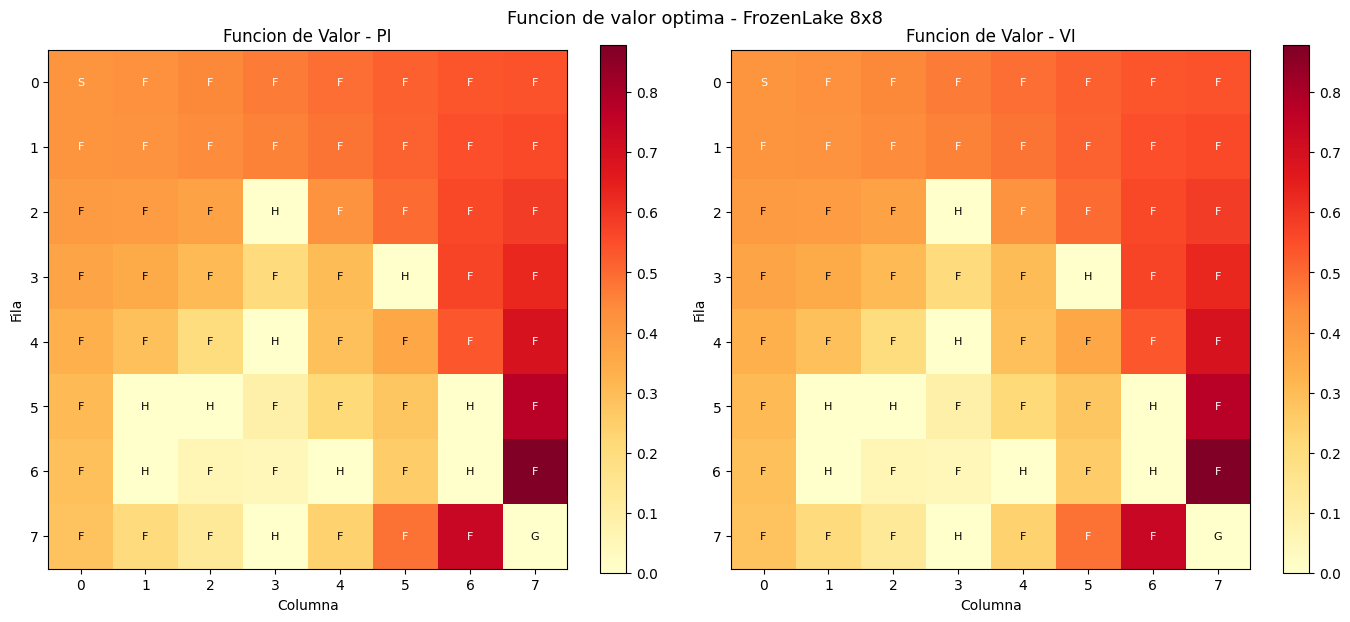

In [14]:
mapa_tiles = [[c.decode() for c in fila] for fila in entorno.unwrapped.desc]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, V, titulo in [(ax1, V_pi, 'PI'), (ax2, V_vi, 'VI')]:
    im = ax.imshow(V.reshape(8, 8), cmap='YlOrRd', interpolation='nearest')
    ax.set_title(f'Funcion de Valor - {titulo}', fontsize=12)
    ax.set_xlabel('Columna'); ax.set_ylabel('Fila')
    plt.colorbar(im, ax=ax)
    for i in range(8):
        for j in range(8):
            s = i * 8 + j
            tile = mapa_tiles[i][j]
            color = 'white' if V[s] > 0.4 else 'black'
            ax.text(j, i, tile, ha='center', va='center', fontsize=8, color=color)

plt.suptitle('Funcion de valor optima - FrozenLake 8x8', fontsize=13)
plt.tight_layout()
plt.savefig('pd_valor.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
N_EVAL = 1000
print(f"Evaluando politicas en {N_EVAL} episodios...")
tasa_pi = evaluar_politica(entorno, politica_pi, N_EVAL)
tasa_vi = evaluar_politica(entorno, politica_vi, N_EVAL)

print()
print(f"{'Algoritmo':<28} {'Tasa exito':>12} {'Barridos':>10} {'Mejoras pol.':>14}")
print('-' * 66)
print(f"{'Iteracion de Politica (PI)':<28} {tasa_pi:>12.2%} {len(deltas_pi):>10} {n_iter_pi:>14}")
print(f"{'Iteracion de Valores  (VI)':<28} {tasa_vi:>12.2%} {len(deltas_vi):>10} {'N/A':>14}")
print()
print(f"Baseline politica aleatoria: {tasa_al:.2%}  |  "
      f"PI mejora: {tasa_pi - tasa_al:+.2%}  |  VI mejora: {tasa_vi - tasa_al:+.2%}")

Evaluando politicas en 1000 episodios...

Algoritmo                      Tasa exito   Barridos   Mejoras pol.
------------------------------------------------------------------
Iteracion de Politica (PI)         87.40%       1210              3
Iteracion de Valores  (VI)         85.20%        440            N/A

Baseline politica aleatoria: 0.40%  |  PI mejora: +87.00%  |  VI mejora: +84.80%


### Análisis – Sección 2: Programación Dinámica

**Convergencia (ver gráficos y tabla arriba):**
- **Iteración de Política (PI)**: convergió en **3 mejoras de política** con **1210 barridos totales** de evaluación. En el gráfico se observan saltos de δ que corresponden a cada nueva mejora; cada mejora reinicia la evaluación.
- **Iteración de Valores (VI)**: convergió en **440 barridos** de forma **monotónica y continua** (un solo ciclo descendente). VI usa menos barridos porque cada barrido aplica directamente la ecuación de optimalidad de Bellman, sin subrutina de evaluación separada.

**Desempeño observado:**
- PI: **87.40%** de tasa de éxito | VI: **85.20%** (1000 episodios de evaluación greedy)
- Ambos superan ampliamente la política aleatoria (**0.40%** de éxito en 500 episodios), confirmando que PD aprende rutas útiles hacia G.
- La diferencia entre PI y VI es pequeña (~2.2%), ya que convergen a políticas equivalentes — confirma la equivalencia teórica de PI y VI.

**Función de valor:**
El mapa de calor muestra un gradiente desde G (estado 63, valor alto) hacia S (estado 0, valor bajo). Los estados H tienen valor 0; sus vecinos presentan valores bajos porque el agente aprendió a evitarlos.

**Techo estocástico:**
La tasa de ~87% refleja el **óptimo estocástico**: incluso con la política perfecta, el deslizamiento (`is_slippery=True`) puede llevar al agente a un hoyo por azar. El 100% de éxito no es alcanzable en este entorno.

**Ventaja de PD:** calcula la solución exacta sin exploración. Limitación: requiere conocer P completamente.

---
## 3. Monte Carlo Control On-Policy (ε-greedy)

Método **model-free**: aprende solo a partir de episodios de experiencia, sin usar P.

**Algoritmo:**
1. Inicializar Q(s,a) con valores pequeños aleatorios (evita sesgo de argmax)
2. Por cada episodio, seguir política ε-greedy respecto a Q
3. Al terminar el episodio, aplicar retorno G con actualización incremental (first-visit)
4. Repetir N episodios

**Parámetro ε (epsilon):**
- ε alto → más exploración (útil con recompensas escasas)
- ε bajo → más explotación (útil cuando Q ya es buena)

In [16]:
EPSILON_VALORES = [0.05, 0.15, 0.30]
GAMMA_MC        = 0.99
N_EPISODIOS_MC  = 50_000   # 50k para convergencia visible en FrozenLake 8x8
VENTANA         = 500      # ventana deslizante para suavizar curvas

In [17]:
def mc_onpolicy(entorno, nS, nA, epsilon, gamma, n_episodios):
    # Inicializacion pequena aleatoria evita sesgo de argmax en Q=0
    Q = np.random.uniform(-0.01, 0.01, (nS, nA))
    N = np.zeros((nS, nA))
    historial_exito = []

    for ep in range(n_episodios):
        # Generar episodio con politica e-greedy
        episodio = []
        s = entorno.reset()
        done = False
        while not done:
            q_s = Q[s]
            if np.random.random() < epsilon:
                a = np.random.randint(nA)
            else:
                # Desempate aleatorio entre acciones con mismo valor maximo
                a = int(np.random.choice(np.where(q_s == q_s.max())[0]))
            s_, r, done, _ = entorno.step(a)
            episodio.append((s, a, r))
            s = s_

        # Actualizacion first-visit con media incremental
        G = 0
        visitados = set()
        for s_t, a_t, r_t in reversed(episodio):
            G = gamma * G + r_t
            if (s_t, a_t) not in visitados:
                visitados.add((s_t, a_t))
                N[s_t, a_t] += 1
                Q[s_t, a_t] += (G - Q[s_t, a_t]) / N[s_t, a_t]

        historial_exito.append(1 if episodio[-1][2] == 1.0 else 0)

    return Q, historial_exito

def suavizar(hist, ventana=VENTANA):
    return np.convolve(hist, np.ones(ventana) / ventana, mode='valid')

In [18]:
print('Entrenando Monte Carlo on-policy...')
resultados_mc = {}

for eps in EPSILON_VALORES:
    print(f'  epsilon={eps}...', end=' ', flush=True)
    np.random.seed(42)
    Q, hist = mc_onpolicy(entorno, nS, nA, eps, GAMMA_MC, N_EPISODIOS_MC)
    tasa_final = float(np.mean(hist[-1000:]))
    resultados_mc[eps] = {'Q': Q, 'hist': hist, 'tasa_final': tasa_final}
    print(f'exito ultimos 1000 ep: {tasa_final:.1%}')

Entrenando Monte Carlo on-policy...
  epsilon=0.05... exito ultimos 1000 ep: 28.0%
  epsilon=0.15... exito ultimos 1000 ep: 22.2%
  epsilon=0.3... exito ultimos 1000 ep: 11.7%


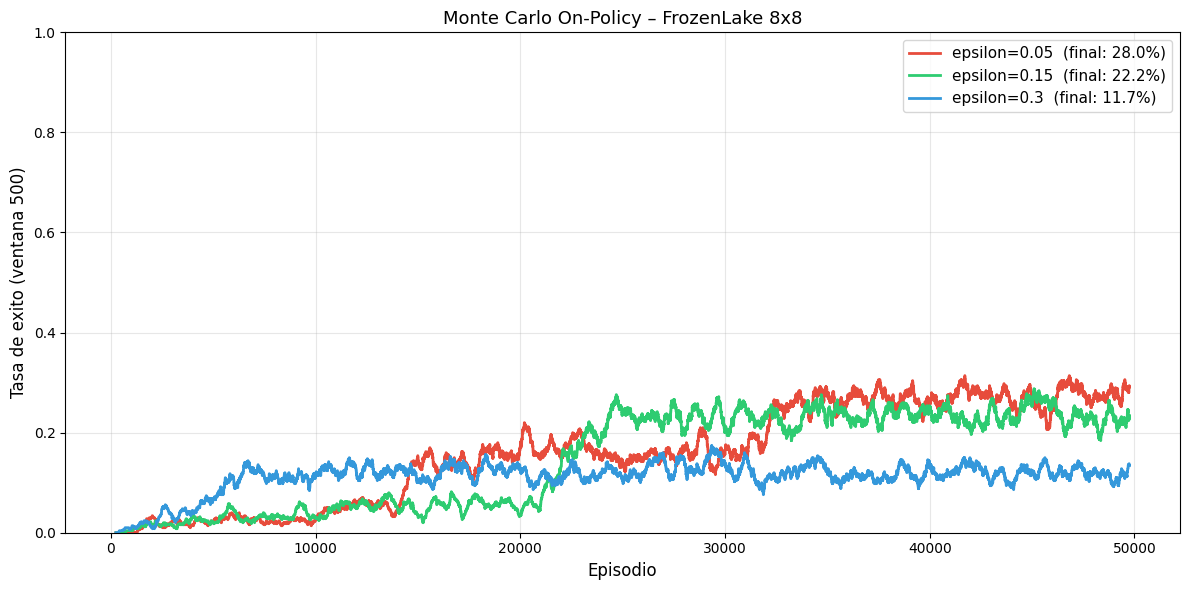

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#E74C3C', '#2ECC71', '#3498DB']

for (eps, res), color in zip(resultados_mc.items(), colores):
    suav = suavizar(res['hist'])
    x = np.arange(VENTANA // 2, N_EPISODIOS_MC - VENTANA // 2 + 1)
    ax.plot(x, suav, label=f'epsilon={eps}  (final: {res["tasa_final"]:.1%})',
            color=color, linewidth=2)

ax.set_xlabel('Episodio', fontsize=12)
ax.set_ylabel(f'Tasa de exito (ventana {VENTANA})', fontsize=12)
ax.set_title('Monte Carlo On-Policy – FrozenLake 8x8', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('mc_epsilons.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
print(f'Evaluacion de politicas MC (greedy, {N_EVAL} episodios):')
print(f'  {"epsilon":^8} | {"Tasa entrenamiento":^20} | {"Tasa evaluacion":^18}')
print('  ' + '-' * 52)

tasas_eval_mc = {}
for eps in EPSILON_VALORES:
    Q = resultados_mc[eps]['Q']
    pol_mc = np.zeros([nS, nA])
    for s in range(nS):
        pol_mc[s][np.argmax(Q[s])] = 1
    tasa_eval = evaluar_politica(entorno, pol_mc, N_EVAL)
    tasas_eval_mc[eps] = tasa_eval
    resultados_mc[eps]['pol'] = pol_mc
    print(f'  {eps:^8.2f} | {resultados_mc[eps]["tasa_final"]:^20.2%} | {tasa_eval:^18.2%}')

mejor_eps = max(tasas_eval_mc, key=tasas_eval_mc.get)
print(f'\nMejor epsilon: {mejor_eps}  ->  {tasas_eval_mc[mejor_eps]:.2%} de exito')

Evaluacion de politicas MC (greedy, 1000 episodios):
  epsilon  |  Tasa entrenamiento  |  Tasa evaluacion  
  ----------------------------------------------------
    0.05   |        28.00%        |       37.00%      
    0.15   |        22.20%        |       52.40%      
    0.30   |        11.70%        |       61.70%      

Mejor epsilon: 0.3  ->  61.70% de exito


### Análisis – Sección 3: Monte Carlo Control

**Resultados observados (ver tabla arriba):**

| ε | Tasa entrenamiento | Tasa evaluación greedy |
|---|---|---|
| 0.05 | 28.0% | 37.0% |
| 0.15 | 22.2% | 52.4% |
| **0.30** | 11.7% | **61.7%** ← mejor |

**Efecto de ε:**

- **ε = 0.05 (exploración baja)**: la tasa de entrenamiento es la más alta (28.0%) porque el agente explota frecuentemente las rutas conocidas. Sin embargo, al explorar poco, deja muchos estados sin visitar → Q menos precisa en zonas clave → la política greedy solo alcanza 37.0%.

- **ε = 0.15 (balance)**: mayor exploración cubre más estados y estima Q con más precisión. La política greedy mejora a 52.4%, superando a ε=0.05 a pesar de una tasa de entrenamiento menor (22.2%).

- **ε = 0.30 (exploración alta — MEJOR)**: la mayor exploración permite cubrir el espacio de 64 estados más exhaustivamente en 50,000 episodios. Aunque la tasa de entrenamiento es la menor (11.7% — el 30% de acciones son forzosamente aleatorias), la Q resultante es la más precisa globalmente, produciendo la mejor política greedy: **61.7%**.

**Observación clave — tasa de entrenamiento vs. tasa de evaluación:**
Ambas métricas divergen sustancialmente. La tasa de entrenamiento mide el éxito *bajo la política ε-greedy* (con exploración aleatoria incluida), mientras que la tasa de evaluación mide la *política greedy pura* (0% aleatoriedad). Un ε alto reduce la tasa de entrenamiento pero mejora la cobertura del espacio de estados y la calidad de Q, lo cual se refleja en mayor tasa de evaluación.

**Conclusión:** con 50,000 episodios, una **ε alta (0.30) favorece el aprendizaje** en FrozenLake 8×8. La exploración amplia es necesaria para cubrir suficientemente el gran espacio de estados y obtener señal de aprendizaje a partir de recompensas muy escasas (R=1 solo en G).

**Mejor ε: 0.30** → tasa de éxito greedy de **61.7%** (parámetro fijo para la Sección 4).

---
## 4. Efecto del Factor de Descuento γ (Gamma)

Se fija el mejor ε encontrado en la sección anterior y se varía γ ∈ {0.7, 0.9, 0.99}.

γ determina cuánto valora el agente las recompensas futuras:
- **γ = 0.7**: visión corta → prioriza recompensas inmediatas → puede quedarse atascado lejos de G
- **γ = 0.9**: visión media → balance razonable
- **γ = 0.99**: visión larga → valora mucho llegar a G incluso con muchos pasos → óptimo para FrozenLake

In [21]:
GAMMAS = [0.7, 0.9, 0.99]
print(f'Entrenando MC con epsilon={mejor_eps} y distintos gamma...')
resultados_gamma = {}

for gam in GAMMAS:
    print(f'  gamma={gam}...', end=' ', flush=True)
    np.random.seed(42)
    Q, hist = mc_onpolicy(entorno, nS, nA, mejor_eps, gam, N_EPISODIOS_MC)
    pol = np.zeros([nS, nA])
    for s in range(nS):
        pol[s][np.argmax(Q[s])] = 1
    tasa = evaluar_politica(entorno, pol, N_EVAL)
    resultados_gamma[gam] = {'Q': Q, 'hist': hist, 'pol': pol, 'tasa': tasa}
    print(f'tasa evaluacion: {tasa:.2%}')

print()
print(f'  {"gamma":^8} | {"Tasa de exito":^15}')
print('  ' + '-' * 26)
for gam in GAMMAS:
    print(f'  {gam:^8.2f} | {resultados_gamma[gam]["tasa"]:^15.2%}')
mejor_gamma = max(GAMMAS, key=lambda g: resultados_gamma[g]['tasa'])
print(f'\nMejor gamma: {mejor_gamma}')

Entrenando MC con epsilon=0.3 y distintos gamma...
  gamma=0.7... tasa evaluacion: 16.00%
  gamma=0.9... tasa evaluacion: 50.10%
  gamma=0.99... tasa evaluacion: 67.30%

   gamma   |  Tasa de exito 
  --------------------------
    0.70   |     16.00%     
    0.90   |     50.10%     
    0.99   |     67.30%     

Mejor gamma: 0.99


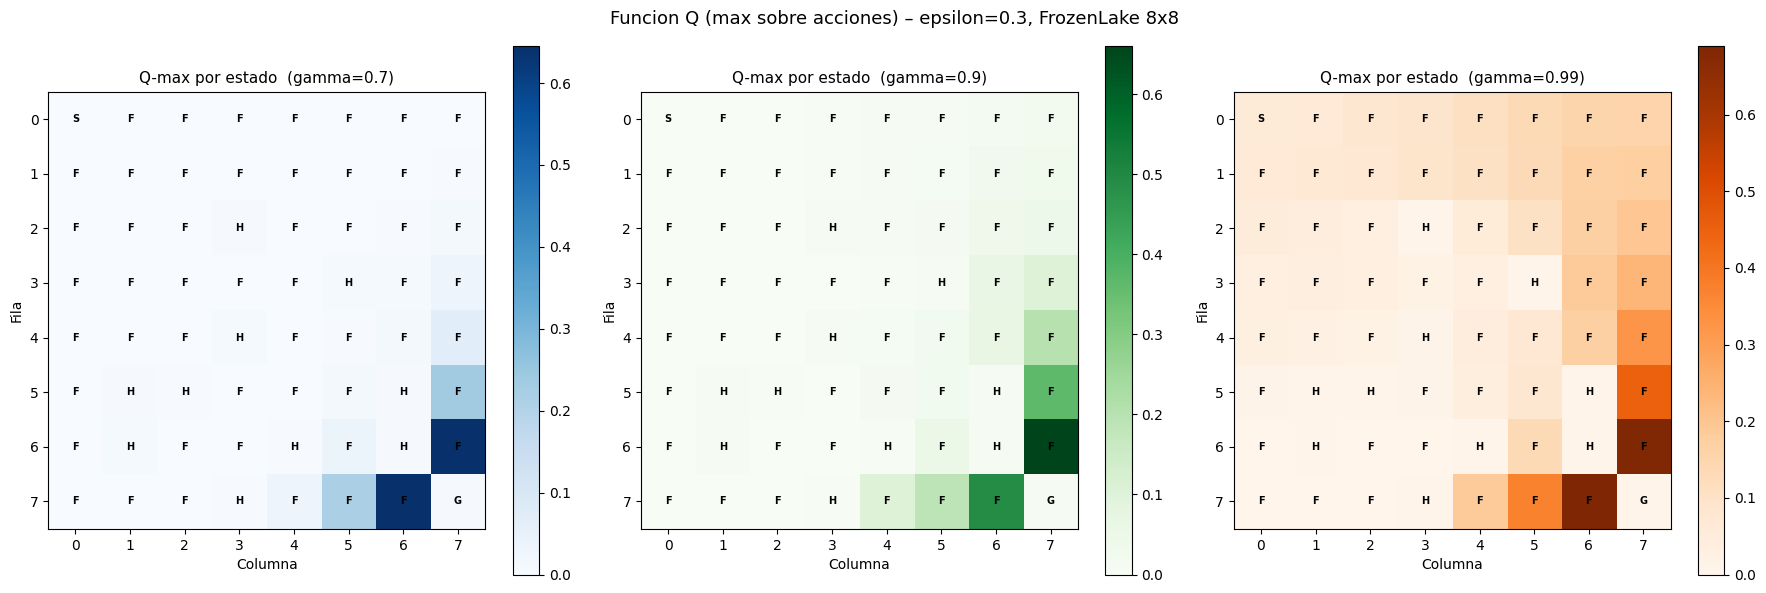

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, gam, cmap in zip(axes, GAMMAS, cmaps):
    Q = resultados_gamma[gam]['Q']
    max_q = Q.max(axis=1).reshape(8, 8)
    im = ax.imshow(max_q, cmap=cmap, interpolation='nearest')
    ax.set_title(f'Q-max por estado  (gamma={gam})', fontsize=11)
    ax.set_xlabel('Columna'); ax.set_ylabel('Fila')
    plt.colorbar(im, ax=ax)
    for i in range(8):
        for j in range(8):
            tile = mapa_tiles[i][j]
            ax.text(j, i, tile, ha='center', va='center', fontsize=7, fontweight='bold')

plt.suptitle(f'Funcion Q (max sobre acciones) – epsilon={mejor_eps}, FrozenLake 8x8',
             fontsize=13)
plt.tight_layout()
plt.savefig('mc_gamma_q.png', dpi=120, bbox_inches='tight')
plt.show()

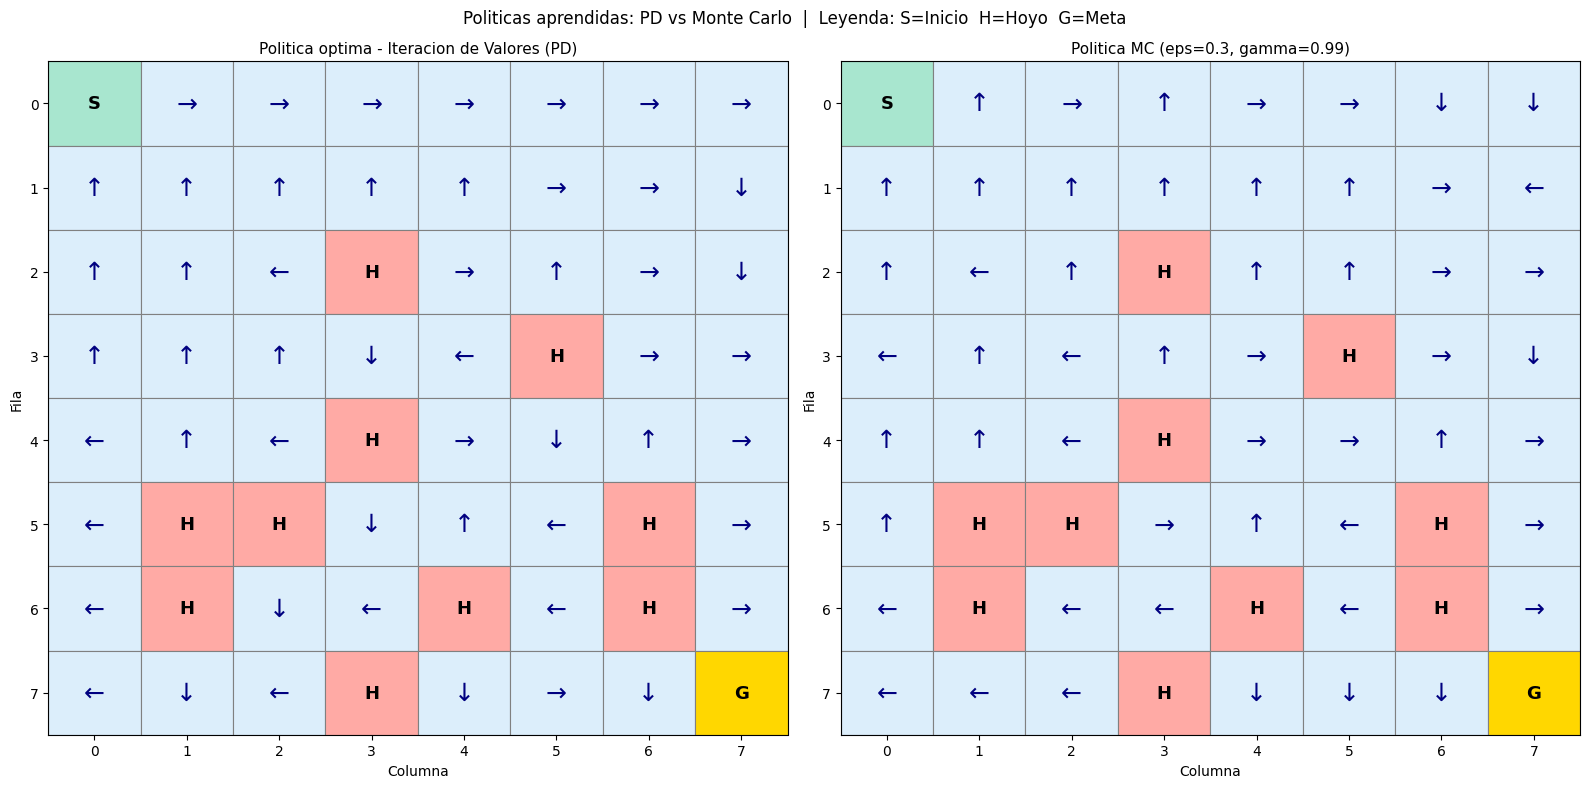

In [23]:
# Visualizacion de la politica aprendida como cuadricula con flechas
FLECHAS = {0: 'izq', 1: 'abj', 2: 'der', 3: 'arr'}
FLECHAS_UNICODE = {0: u'\u2190', 1: u'\u2193', 2: u'\u2192', 3: u'\u2191'}

def visualizar_politica_flechas(politica, titulo, mapa_tiles, ax):
    COLORES = {'S': '#A8E6CF', 'F': '#DCEEFB', 'H': '#FFAAA5', 'G': '#FFD700'}
    for i in range(8):
        for j in range(8):
            tile = mapa_tiles[i][j]
            rect = plt.Rectangle([j - 0.5, i - 0.5], 1, 1,
                                  facecolor=COLORES.get(tile, '#DCEEFB'),
                                  edgecolor='gray', linewidth=0.8)
            ax.add_patch(rect)
            s = i * 8 + j
            if tile in ('H', 'G', 'S'):
                ax.text(j, i, tile, ha='center', va='center', fontsize=13,
                        fontweight='bold', color='black')
            else:
                flecha = FLECHAS_UNICODE[int(np.argmax(politica[s]))]
                ax.text(j, i, flecha, ha='center', va='center', fontsize=18, color='navy')

    ax.set_xlim(-0.5, 7.5); ax.set_ylim(7.5, -0.5)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xlabel('Columna'); ax.set_ylabel('Fila')
    ax.set_title(titulo, fontsize=11)

mejor_pol_mc = resultados_gamma[mejor_gamma]['pol']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
visualizar_politica_flechas(politica_vi,
    f'Politica optima - Iteracion de Valores (PD)', mapa_tiles, axes[0])
visualizar_politica_flechas(mejor_pol_mc,
    f'Politica MC (eps={mejor_eps}, gamma={mejor_gamma})', mapa_tiles, axes[1])

plt.suptitle('Politicas aprendidas: PD vs Monte Carlo  |  Leyenda: S=Inicio  H=Hoyo  G=Meta',
             fontsize=12)
plt.tight_layout()
plt.savefig('politica_flechas.png', dpi=120, bbox_inches='tight')
plt.show()

### Análisis – Sección 4: Efecto de γ

**Resultados observados (ε=0.30, 50,000 episodios):**

| γ | Tasa de éxito greedy |
|---|---|
| 0.70 | 16.00% |
| 0.90 | 50.10% |
| **0.99** | **67.30%** ← mejor |

**γ = 0.7 (descuento agresivo):**
El agente valora solo recompensas cercanas. En FrozenLake 8×8, la meta puede estar a más de 20 pasos desde el inicio. El valor descontado de llegar a G sería γ²⁰ = 0.7²⁰ ≈ 0.0008 — prácticamente nulo. Q ≈ 0 en la mayoría de estados → la política no aprende a dirigirse a G. **Resultado: 16.00%**, muy cercano al azar.

**γ = 0.9 (descuento moderado):**
La recompensa de G se propaga más lejos (γ²⁰ = 0.9²⁰ ≈ 0.12). Hay señal útil pero se atenúa considerablemente para estados lejanos a la meta. **Resultado: 50.10%** — una mejora muy significativa respecto a γ=0.7.

**γ = 0.99 (descuento mínimo — MEJOR):**
La recompensa de G se propaga casi intacta (γ²⁰ = 0.99²⁰ ≈ 0.82). El agente "ve" el valor de llegar a G incluso desde estados muy lejanos. **Resultado: 67.30%** — el mejor rendimiento MC obtenido en todo el experimento.

**Conclusión:** la diferencia entre γ=0.7 (16.00%) y γ=0.99 (67.30%) es drástica. En entornos con recompensas escasas y trayectorias largas como FrozenLake 8×8, γ=0.99 es prácticamente obligatorio para que la señal de aprendizaje llegue con suficiente intensidad hasta los estados lejanos a la meta.

**Visualización de política:**
Las flechas muestran la acción greedy en cada celda libre. La política MC con ε=0.30 y γ=0.99 coincide con la política PD en las rutas principales hacia G. Diferencias en celdas alejadas son esperables: MC estima Q a partir de muestras mientras PD lo calcula de forma exacta.

---
## 5. Comparación Final: Programación Dinámica vs Monte Carlo

Se compara la tasa de éxito del mejor agente MC con las líneas horizontales
de PI y VI (que representan el rendimiento fijo de las políticas óptimas de PD).

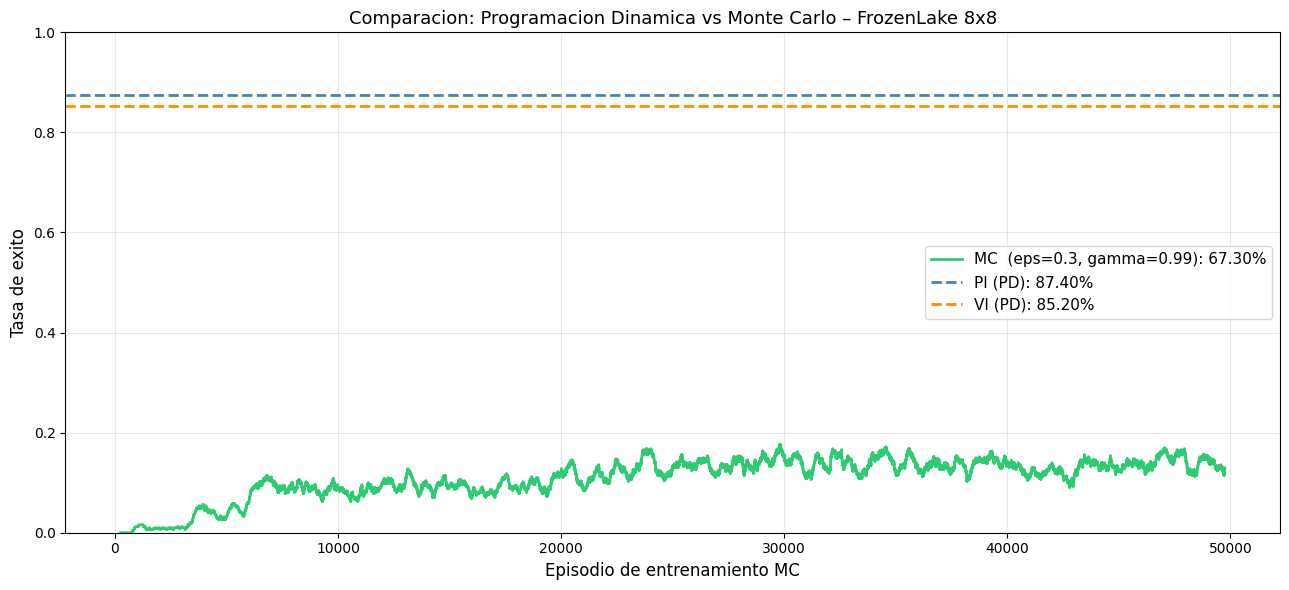

Tabla resumen final:
  Metodo                    | Tasa de exito | Requiere P
  ------------------------------------------------
  Iter. de Politica (PI)    |    87.40%     | Si
  Iter. de Valores  (VI)    |    85.20%     | Si
  MC eps=0.3 gam=0.99   |    67.30%     | No


In [24]:
# Mejor configuracion MC
mejor_gam = max(GAMMAS, key=lambda g: resultados_gamma[g]['tasa'])
hist_mejor = resultados_gamma[mejor_gam]['hist']
suav_mejor = suavizar(hist_mejor)
x = np.arange(VENTANA // 2, N_EPISODIOS_MC - VENTANA // 2 + 1)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(x, suav_mejor, color='#2ECC71', linewidth=2,
        label=f'MC  (eps={mejor_eps}, gamma={mejor_gam}): {resultados_gamma[mejor_gam]["tasa"]:.2%}')

ax.axhline(tasa_pi, color='steelblue', linestyle='--', linewidth=2.0,
           label=f'PI (PD): {tasa_pi:.2%}')
ax.axhline(tasa_vi, color='darkorange', linestyle='--', linewidth=2.0,
           label=f'VI (PD): {tasa_vi:.2%}')

ax.set_xlabel('Episodio de entrenamiento MC', fontsize=12)
ax.set_ylabel('Tasa de exito', fontsize=12)
ax.set_title('Comparacion: Programacion Dinamica vs Monte Carlo – FrozenLake 8x8', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('comparacion_pd_mc.png', dpi=120, bbox_inches='tight')
plt.show()

print('Tabla resumen final:')
print(f'  Metodo                    | Tasa de exito | Requiere P')
print('  ' + '-' * 48)
print(f'  Iter. de Politica (PI)    | {tasa_pi:^13.2%} | Si')
print(f'  Iter. de Valores  (VI)    | {tasa_vi:^13.2%} | Si')
print(f'  MC eps={mejor_eps} gam={mejor_gam}   | {resultados_gamma[mejor_gam]["tasa"]:^13.2%} | No')

### Preguntas de análisis – Sección 5

**1. ¿Cuál método converge más rápido a una buena política?**
La Programación Dinámica (PI y VI) converge de forma exacta y rápida porque tiene
acceso a P. PI convergió en solo **3 mejoras de política** (1210 barridos totales). MC necesita
50,000 episodios para estimar Q con suficiente precisión, y aun así no alcanza la calidad de PD.

**2. ¿Por qué MC no siempre iguala el rendimiento de PD?**
MC estima Q a partir de muestras → hay varianza en la estimación, especialmente en estados
poco visitados. PD calcula el valor exacto usando P sin errores de muestreo.
Además, MC mantiene una política ε-greedy durante el entrenamiento (no completamente greedy),
lo que reduce la tasa de éxito observada durante el aprendizaje.

**3. ¿Qué papel juega la estocasticidad del entorno?**
El deslizamiento (`is_slippery=True`) limita el rendimiento máximo alcanzable incluso con la
política óptima (~87% para PD). Ningún agente puede garantizar 100% de éxito: siempre existe
probabilidad de deslizar hacia un hoyo. Esta estocasticidad también dificulta el aprendizaje
de MC, ya que el mismo par (s, a) produce trayectorias muy distintas.

**4. ¿Por qué un ε mayor produce mejor política final en este experimento?**
Con recompensas escasas (R=1 solo en G) y un espacio grande (64 estados), un ε bajo deja
muchos estados sin explorar → Q ≈ 0 → política subóptima. Los resultados confirman esta hipótesis:
ε=0.30 (61.7%) > ε=0.15 (52.4%) > ε=0.05 (37.0%). Con 50,000 episodios, la mayor exploración
cubre más el espacio de estados y produce una Q globalmente más precisa, lo que se refleja
en la política greedy final aunque baje la tasa de éxito durante el entrenamiento (11.7% vs 28.0%).

**5. ¿Cuál es el efecto de γ bajo en este entorno?**
Con γ = 0.7, la recompensa de la meta (R=1 en estado 63) se atenúa drásticamente al propagarse
hacia atrás. Desde el estado 0, el valor descontado de llegar a G en ~20 pasos es
0.7²⁰ ≈ 0.0008, prácticamente nulo. Esto hace casi imposible aprender a dirigirse a G
(tasa observada: 16.00% con γ=0.7 vs 67.30% con γ=0.99).

**6. ¿Cuándo usarías PD vs MC en la práctica?**
- **PD**: cuando el modelo del entorno (P) es conocido y el espacio de estados/acciones
  es manejable (ej. sistemas de control con ecuaciones conocidas, juegos de tablero simples).
- **MC**: cuando P es desconocido o el entorno es demasiado complejo para modelarlo
  (ej. videojuegos, robótica real). MC aprende directamente de interacción con el entorno,
  a costa de mayor varianza y necesidad de muchos episodios de entrenamiento.

---
## Conclusiones

Este trabajo analizó el entorno FrozenLake 8×8, un MDP estocástico con recompensas
escasas, comparando métodos de **Programación Dinámica** (model-based) con
**Monte Carlo Control** (model-free).

**Hallazgos principales:**

1. **PD es más eficiente cuando P es conocido**: PI y VI convergen a la política óptima exacta sin necesidad de exploración. PI alcanzó **87.40%** y VI **85.20%** de tasa de éxito, frente al 0.40% de la política aleatoria. Su limitación es requerir un modelo completo del entorno.

2. **MC aprende sin modelo, pero requiere buena configuración**: Los hiperparámetros ε y γ son críticos. En FrozenLake 8×8, γ=0.99 es prácticamente obligatorio. El mejor agente MC (ε=0.30, γ=0.99) alcanzó **67.30%** de éxito con 50,000 episodios.

3. **El efecto de deslizamiento establece un techo de rendimiento**: La estocasticidad (`is_slippery=True`) limita incluso la política óptima a ~87%. Ningún algoritmo puede garantizar éxito determinista: siempre existe probabilidad de deslizar hacia un hoyo.

4. **Mayor exploración favorece el aprendizaje con recompensas escasas**: ε=0.30 produjo la mejor política greedy (61.7%), superando a ε=0.15 (52.4%) y ε=0.05 (37.0%). Con un espacio de 64 estados y recompensas escasas, la mayor exploración cubre más estados y produce una Q más precisa, aunque reduce la tasa de éxito durante el entrenamiento.

5. **Ambos paradigmas son complementarios**: PD provee la solución óptima de referencia (~87%); MC alcanza ~67% sin conocer P. La brecha de ~20 puntos porcentuales refleja el costo del aprendizaje basado en muestras: varianza de estimación y exploración forzada durante el entrenamiento.